# Consumindo APIs que precisam de keys

Fonte: https://fred.stlouisfed.org/

Agora, precisamos de uma key para consumir a API. Para isso, é necessário criar uma conta no site e gerar uma key. A key é um código que identifica o usuário e permite o acesso à API. Este é um cenário muito comum, pois muitas APIs são pagas e precisam de uma key para serem consumidas. Neste caso, a API é gratuita e a key é gerada automaticamente.

>  "This product uses the FRED® API but is not endorsed or certified by the Federal Reserve Bank of St. Louis."

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

key = os.getenv("FRED_API_KEY")


In [2]:
SERIE_DOLLAR = "DEXBZUS"

URL_SERIE_DOLLAR = f"https://api.stlouisfed.org/fred/series/observations?series_id={SERIE_DOLLAR}&api_key={key}&file_type=json"


In [3]:
import requests

resposta_dollar = requests.get(URL_SERIE_DOLLAR)

resposta_dollar.status_code

200

In [4]:
# resposta_dollar.json()

In [5]:
import pandas as pd

df_dollar = pd.DataFrame(resposta_dollar.json()["observations"])
df_dollar.head()

,realtime_start,realtime_end,date,value
0,2023-08-10,2023-08-10,1995-01-02,0.8440
1,2023-08-10,2023-08-10,1995-01-03,0.8450
2,2023-08-10,2023-08-10,1995-01-04,0.8450
3,2023-08-10,2023-08-10,1995-01-05,0.8430
4,2023-08-10,2023-08-10,1995-01-06,0.8400


In [6]:
df_dollar.tail()

,realtime_start,realtime_end,date,value
7455,2023-08-10,2023-08-10,2023-07-31,4.7407
7456,2023-08-10,2023-08-10,2023-08-01,4.7824
7457,2023-08-10,2023-08-10,2023-08-02,4.814
7458,2023-08-10,2023-08-10,2023-08-03,4.882
7459,2023-08-10,2023-08-10,2023-08-04,4.8548


In [7]:
df_dollar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7460 entries, 0 to 7459
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   realtime_start  7460 non-null   object
 1   realtime_end    7460 non-null   object
 2   date            7460 non-null   object
 3   value           7460 non-null   object
dtypes: object(4)
memory usage: 233.3+ KB


In [8]:
# drop das colunas que não serão utilizadas
df_dollar = df_dollar.drop(columns=["realtime_start", "realtime_end"])

# converter a coluna date para datetime
df_dollar["date"] = pd.to_datetime(df_dollar["date"])

df_dollar.head()


,date,value
0,1995-01-02,0.8440
1,1995-01-03,0.8450
2,1995-01-04,0.8450
3,1995-01-05,0.8430
4,1995-01-06,0.8400


In [9]:
# verificando se a coluna value possui realmente apenas números
df_dollar["value"].value_counts()


.         287
1.8050     14
1.7700      8
1.8000      8
2.9450      7
         ... 
1.6249      1
1.6316      1
1.6392      1
1.6405      1
4.8548      1
Name: value, Length: 5556, dtype: int64

In [10]:
df_dollar["value"].value_counts(ascending=True)


1.6574      1
3.1226      1
3.1604      1
3.1446      1
3.1103      1
         ... 
1.7900      7
1.7700      8
1.8000      8
1.8050     14
.         287
Name: value, Length: 5556, dtype: int64

In [11]:
# substituindo os valores "." por NaN
df_dollar["value"] = df_dollar["value"].replace(".", float("NaN"))

# converter a coluna value para float
df_dollar["value"] = df_dollar["value"].astype(float)

# colocar a coluna date como index
df_dollar = df_dollar.set_index("date")


In [12]:
df_dollar.head()

,value
date,
1995-01-02,0.844
1995-01-03,0.845
1995-01-04,0.845
1995-01-05,0.843
1995-01-06,0.840


In [13]:
df_dollar.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7460 entries, 1995-01-02 to 2023-08-04
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   7173 non-null   float64
dtypes: float64(1)
memory usage: 116.6 KB


<Axes: xlabel='date'>

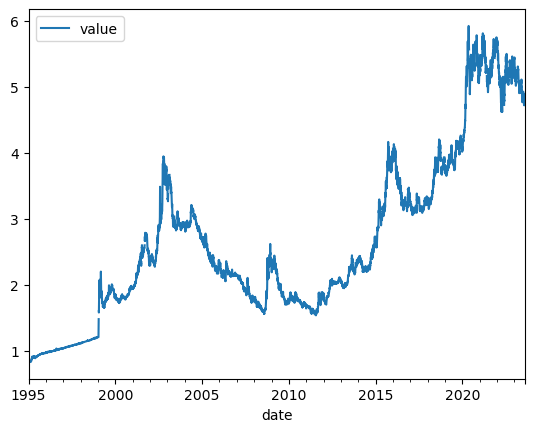

In [14]:
df_dollar.plot()

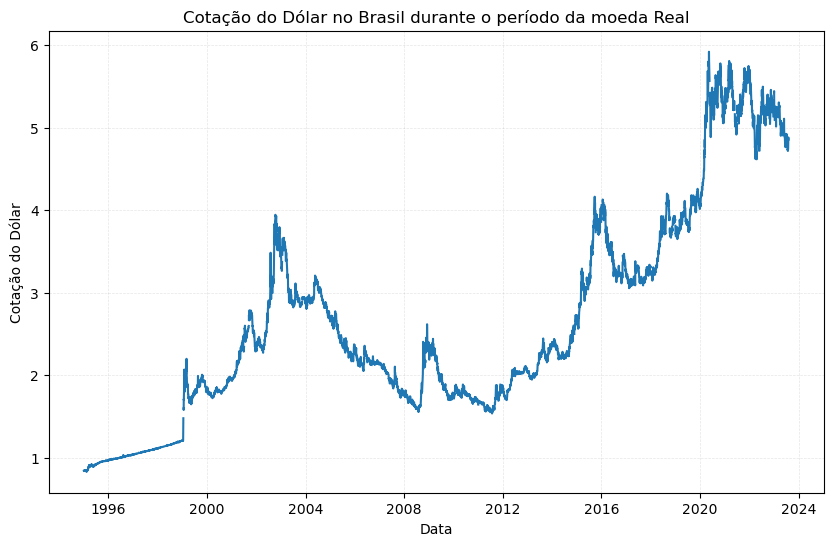

In [15]:
# criando uma figura com o matplotlib, definindo o tamanho
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# plotando o gráfico
ax.plot(df_dollar.index, df_dollar["value"])
ax.set_title("Cotação do Dólar no Brasil durante o período da moeda Real")
ax.set_ylabel("Cotação do Dólar")
ax.set_xlabel("Data")

ax.grid(linestyle="--", linewidth=0.5, color="black", alpha=0.1)

plt.show()